## Polynomial fit
oop implementation of a polynomial fit using least squares.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class polyfit:
    """
    polynomial fitting using least squares
    initialise: instance = polyfit(xdata,ydata,order=2)
        - xdata: list of x-data, each value unique
        - ydata: list of y-data, corresponding to x
        - order: order of fitting polynomial (default=2)
    attributes:
        - instance.order: order of fitting polynomial
        - instance.coeff: polynomial coeffcients (decreasing order)
    methods:
        - instance(x): evaluates polynomial at points x (list) 
    """
    
    def __init__(self,xdata,ydata,order=2):
        # input
        xdata = np.array(xdata)
        ydata = np.array(ydata)
        self.order = order
        # create polynomial from least squares fit
        self.coeff = self.__calc_coeff(xdata,ydata)
        # print polynomial formula
        print(self)
    
    def __call__(self,x):
        # evaluate polynomial at vector x
        x = np.array(x)
        y = self.__Vandermonde(x) @ self.coeff
        return y
    
    def __str__(self):
        # polynomial as string
        def fcoeff(i):
            return f' {"{0:+.3g}".format(self.coeff[i])}' # plus sign & rounding
        polstr = ''
        for i in range(self.order-1):
            polstr += fcoeff(i) + f'*x**{self.order-i}'
        if self.order > 0:
            polstr += fcoeff(-2) + '*x'
        polstr += fcoeff(-1)
        return 'polynomial: f(x) =' + polstr

    def __calc_coeff(self,x,y):
        # calculation of polynomial coefficients (decreasing order)
        V = self.__Vandermonde(x)
        B = np.transpose(V)
        return np.linalg.inv( B @ V ) @ ( B @ y )  
    
    def __Vandermonde(self,x):
        # coefficient matrix for polynomial interpolation
        V = [ x**(self.order-n) for n in range(self.order+1) ]
        return np.transpose(np.array(V))

- input

In [3]:
N_data = 30   # number of data points
N      = 2    # polynomial order ( N << N_data )

- test data: cosine + noise

In [4]:
data_x = np.linspace(-2,2,N_data)
data_y = np.cos(data_x)
data_y += 0.2*(np.random.rand(np.shape(data_x)[0])-0.5)   # adding noise

- create polyfit object

In [5]:
p1 = polyfit(data_x, data_y, N)

polynomial: f(x) = -0.362*x**2 +0.00716*x +0.936


- comparison of polynomial coefficients with NumPy

In [6]:
coeff_np  = np.polyfit(data_x, data_y, N)
print(f'max. difference coefficients: {max(abs(p1.coeff-coeff_np))}')

max. difference coefficients: 1.2212453270876722e-15


- plot

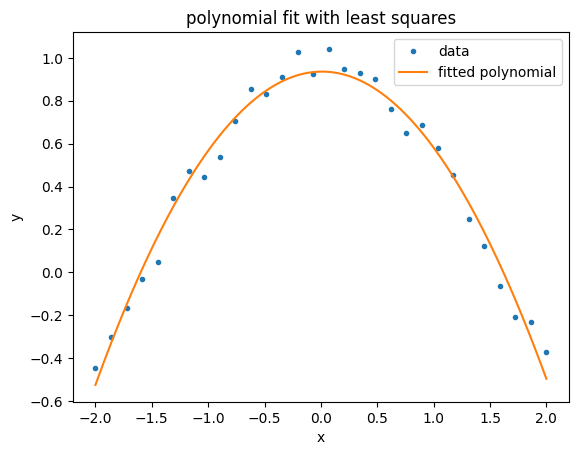

In [7]:
plot_x = np.linspace(-2,2,100)
plot_y = p1(plot_x)

plt.plot(data_x, data_y, '.', label='data')
plt.plot(plot_x, plot_y, label='fitted polynomial')
plt.legend()
plt.title('polynomial fit with least squares')
plt.xlabel('x')
plt.ylabel('y')
plt.show()